<a href="https://colab.research.google.com/github/davidpalacio1/TP-1-LDD/blob/main/TP_2_LDD_versionCasiFinal_Revisar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP2 - Laboratorio de Datos**
# **Encuesta Permanente de Hogares (EPH) - Argentina**

Universidad de Buenos Aires
Facultad de Ciencias Exactas y Naturales (FCEyN)
<br>

### Verano 2026

**Integrantes:** Lautaro Herrera - Nicolas Corral - David Palacio Velásquez
<br>
**Fecha:** 9 de marzo de 2026  

<br>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


# Limpieza de datos

Esta tabla contiene muchas variables, y la gran mayoría de ellas son categóricas, por ejemplo REGION (01 = Gran Buenos Aires, 40 = Noroeste, ...). La información de todas la variables puede verse en el archivo EPH_registro_3T2025.pdf, en la sección “Diseño de registros de la base Personas” (que es la base que estamos usando). Armamos un dataset de trabajo dejando solo algunas filas y columnas. Los pasos que se proponen a
continuación pueden seguirlos paso a paso o pueden hacer modificaciones si las consideran apropiadas, por ejemplo utilizar algunas variables más o menos de las que proponemos.

##Ejercicio 1

Leer el archivo a un DataFrame (usar sep = ";" dado que el archivo tiene valores separados
por ;)

In [2]:
# Leemos el archivo con los datos a analizar:

df = pd.read_csv("usu_individual_T325.txt", sep = ";")

/tmp/ipykernel_35114/2148691374.py:3: DtypeWarning: Columns (102) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("usu_individual_T325.txt", sep = ";")


In [3]:
df

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44941,TQRMNOPXUHJOLQCDEHLEH00862602,2025,3,2,5,0,40,N,25,227,...,0,0,0,0,2.0,2.0,NaN,2.0,2.0,2.0
44942,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,1,1,40,N,25,336,...,0,0,0,0,7.0,9.0,NaN,8.0,8.0,10.0
44943,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,2,1,40,N,25,336,...,0,0,0,0,7.0,9.0,NaN,8.0,8.0,10.0
44944,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,3,0,40,N,25,336,...,0,0,0,0,7.0,9.0,NaN,8.0,8.0,10.0


In [4]:
print("Las dimensiones de df son :", df.shape)

Las dimensiones de df son : (44946, 235)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44946 entries, 0 to 44945
Columns: 235 entries, CODUSU to P_ADECCF
dtypes: float64(148), int64(81), object(6)
memory usage: 80.6+ MB


In [6]:
print("En df tenemos las columnas :" , list(df.columns))

En df tenemos las columnas : ['CODUSU', 'ANO4', 'TRIMESTRE', 'NRO_HOGAR', 'COMPONENTE', 'H15', 'REGION', 'MAS_500', 'AGLOMERADO', 'PONDERA', 'CH03', 'CH04', 'CH05', 'CH06', 'CH07', 'CH08', 'CH09', 'CH10', 'CH11', 'CH12', 'CH13', 'CH14', 'CH15', 'CH15_COD', 'CH16', 'CH16_COD', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'IMPUTA', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP03I', 'PP03J', 'INTENSI', 'PP04A', 'PP04B_COD', 'PP04B1', 'PP04B2', 'PP04B3_MES', 'PP04B3_ANO', 'PP04B3_DIA', 'PP04C', 'PP04C99', 'PP04D_COD', 'PP04G', 'PP05B2_MES', 'PP05B2_ANO', 'PP05B2_DIA', 'PP05C_1', 'PP05C_2', 'PP05C_3', 'PP05E', 'PP05F', 'PP05H', 'PP06A', 'PP06C', 'PP06D', 'PP06E', 'PP06H', 'PP07A', 'PP07C', 'PP07D', 'PP07E', 'PP07F1', 'PP07F2', 'PP07F3', 'PP07F4', 'PP07F5', 'PP07G1', 'PP07G2', 'PP07G3', 'PP07G4', 'PP07G_59', 'PP07H', 'PP07I', 'PP07J', 'PP07K', 'PP08D1', 'PP08D4', 'PP0

## Ejercicio 2

Eliminar a todos los individuos que no completaron la encuesta (columna H15).

In [7]:
# Quienes completaron la encuesta tienen un valor 1 en la columna H15 (Entrevista individual realizada) y quienes no tienen valor 0.
# Para descartar a quienes no completaron la encuesta, nos quedamos con aquellos que tienen valor 1 en ese columna:

df = df[df["H15"] == 1]

In [8]:
df

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
5,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,4,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
6,TQRMNOQSSHKLKRCDEIHJF00868831,2025,3,1,1,1,44,N,31,140,...,0,0,0,0,3.0,2.0,NaN,4.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44939,TQRMNOPXUHJOLQCDEHLEH00862602,2025,3,2,3,1,40,N,25,227,...,0,0,0,0,2.0,2.0,NaN,2.0,2.0,2.0
44940,TQRMNOPXUHJOLQCDEHLEH00862602,2025,3,2,4,1,40,N,25,227,...,0,0,0,0,2.0,2.0,NaN,2.0,2.0,2.0
44942,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,1,1,40,N,25,336,...,0,0,0,0,7.0,9.0,NaN,8.0,8.0,10.0
44943,TQRMNOQPQHMKLQCDEHLEH00891262,2025,3,1,2,1,40,N,25,336,...,0,0,0,0,7.0,9.0,NaN,8.0,8.0,10.0


In [9]:
print("El tamaño inicial de df era (44946, 235), ahora es " , df.shape , ". Es decir, 4947 filas menos.")

El tamaño inicial de df era (44946, 235), ahora es  (39999, 235) . Es decir, 4947 filas menos.


##Ejercicio 3

Seleccionar las siguientes columnas: ”REGION”, ”MAS 500”, ”CH04”, ”CH03”, ”CH06”, ”CH07”, ”CH09”, ”CH10”, ”NIVEL ED”, ”ESTADO”, ”CAT OCUP”, ”CAT INAC”, ”SECTOR”, ”PP02B”, ”PP02C1”, ”PP02C2”, ”PP02C3”, ”PP02C4”, ”PP02C5”, ”PP02C6”, ”PP02C7”, ”PP02C8”, ”PP02D”, ”PP02D”, ”PP02F”, ”PP02G”, ”PP02H”, ”PP02I”,”PP03C”, ”PP03D”, ”PP3E TOT”, ”PP3F TOT”, ”PP03G”, ”PP03H”, ”PP04A”, ”PP04A1”, ”PP04A1”, ”PP04B1”, ”PP04B2”, ”PP04B3 ANO”, ”PP04C”, ”PP03I”, ”PP03J”, ”PP03K”, ”INTENSI”, ”PP04G”, ”P47T”.

In [10]:
# Verificamos si hay duplicados:

df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [11]:
# Las columnnas a seleccionar:

columnas_CORREGIBLE = [
    "REGION", "MAS_500", "CH04", "CH03", "CH06", "CH07",
"CH09", "CH10", "NIVEL_ED", "ESTADO", "CAT_OCUP", "CAT_INAC", "SECTOR", "PP02B",
"PP02C1", "PP02C2", "PP02C3", "PP02C4", "PP02C5", "PP02C6", "PP02C7", "PP02C8",
"PP02D", "PP02D", "PP02F", "PP02G", "PP02H", "PP02I", "PP03C", "PP03D", "PP3E_TOT",
"PP3F_TOT", "PP03G", "PP03H", "PP04A", "PP04A1", "PP04A1", "PP04B1", "PP04B2",
"PP04B3_ANO", "PP04C", "PP03I", "PP03J", "PP03K", "INTENSI", "PP04G", "P47T"
]


In [12]:
# Antes de continuar con la solución de los ejercicios, revisamos si esta lista tiene valores repetidos.

print("La cantidad de elementos en columnas_CORREGIBLE es:" , len(columnas_CORREGIBLE))
print("La cantidad de elementos en columnas_CORREGIBLE sin contar repetidos es:" , len(set(columnas_CORREGIBLE)))

# set() elimina los elementos repetidos. Así, len(columnas_CORREGIBLE) dice el tamaño sin repetidos.

print("¿Hay columnas repetidas? :" , len(columnas_CORREGIBLE) != len(set(columnas_CORREGIBLE)))

La cantidad de elementos en columnas_CORREGIBLE es: 47
La cantidad de elementos en columnas_CORREGIBLE sin contar repetidos es: 45
¿Hay columnas repetidas? : True


In [13]:
# Se encontraron dos elementos repetidos.Los retiramos para evitar errores en lo sucesivo. No usamos set() para esto pues, aunque saca los repetidos, no mantiene el orden y este puede llegar a ser de utilidad más adelante:

columnas = list(dict.fromkeys(columnas_CORREGIBLE))

In [14]:
columnas

['REGION',
 'MAS_500',
 'CH04',
 'CH03',
 'CH06',
 'CH07',
 'CH09',
 'CH10',
 'NIVEL_ED',
 'ESTADO',
 'CAT_OCUP',
 'CAT_INAC',
 'SECTOR',
 'PP02B',
 'PP02C1',
 'PP02C2',
 'PP02C3',
 'PP02C4',
 'PP02C5',
 'PP02C6',
 'PP02C7',
 'PP02C8',
 'PP02D',
 'PP02F',
 'PP02G',
 'PP02H',
 'PP02I',
 'PP03C',
 'PP03D',
 'PP3E_TOT',
 'PP3F_TOT',
 'PP03G',
 'PP03H',
 'PP04A',
 'PP04A1',
 'PP04B1',
 'PP04B2',
 'PP04B3_ANO',
 'PP04C',
 'PP03I',
 'PP03J',
 'PP03K',
 'INTENSI',
 'PP04G',
 'P47T']

In [15]:
df = df[columnas]
df

,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B1,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T
2,42,S,2,1,38,1,1,2,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552000.0
3,42,S,1,2,39,1,1,2,4,1,...,2.0,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0
4,42,S,1,3,18,5,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,42,S,1,3,17,5,1,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,44,N,1,1,50,2,1,2,3,1,...,2.0,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44939,40,N,1,3,13,5,1,1,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
44940,40,N,2,3,12,5,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
44942,40,N,1,1,46,1,1,2,6,1,...,2.0,0.0,0.0,8.0,2.0,2.0,0.0,2.0,11.0,1370000.0
44943,40,N,2,2,38,1,1,2,6,1,...,2.0,0.0,0.0,3.0,1.0,1.0,2.0,1.0,11.0,700000.0


## Ejercicio 4

Muchas de estas columnas contienen datos faltantes, en general por preguntas que no corresponden. Por ejemplo, preguntas sobre ocupación a personas desocupadas. Para las siguientes columnas, reemplazar los datos faltantes por 0: ”EMPLEO”, ”PP03C”, ”PP03D”, ”PP3E TOT”, ”PP3F TOT”, ”PP03G”, ”PP03H”, ”PP03I”, ”PP03J”, ”PP03K”, ”PP04B1”,
”PP04B2”, ”PP04B3 ANO”, ”PP04C”, ”PP04A”, ”PP04A1”, ”PP04G”, ”INTENSI” (la ma-
yoría son variables categóricas que van a ser reemplazadas por dummies para las distintas categorías).

In [16]:
# Columnas para el reemplazo:

columnas_a_reemplazar = [
    "EMPLEO",
    "PP03C", "PP03D","PP3E_TOT","PP03G", "PP03H", "PP03I", "PP03J", "PP03K", "PP04B1","PP04B2", "PP04B3_ANO", "PP04C", "PP04A", "PP04A1", "PP04G", "INTENSI" ]

"EMPLEO" aparece entre las columnas a reemplazar, pero no está entre las columas seleccionadas en el Ejercicio 3. Tenemos dos opciones:

  - Agregar "EMPLEO" a las columnas seleccionadas en 3.
    
  - No tener en cuenta a "EMPLEO" para las columnas seleccionadas y sacarlo de las columnas a reemplazar.
    

Elegimos la primera opción para mantener los datos de "EMPLEO".

In [17]:
df = pd.read_csv("usu_individual_T325.txt", sep = ";")
df = df[df["H15"] == 1] # Hasta acá, lo hecho hasta 2.

# Agregamos a "EMPLEO":

columnas = [
    "EMPLEO",
  'REGION', 'MAS_500', 'CH04', 'CH03', 'CH06', 'CH07', 'CH09', 'CH10', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC', 'SECTOR', 'PP02B', 'PP02C1', 'PP02C2', 'PP02C3', 'PP02C4', 'PP02C5', 'PP02C6', 'PP02C7', 'PP02C8', 'PP02D', 'PP02F', 'PP02G', 'PP02H', 'PP02I', 'PP03C', 'PP03D', 'PP3E_TOT', 'PP3F_TOT', 'PP03G', 'PP03H', 'PP04A', 'PP04A1', 'PP04B1', 'PP04B2', 'PP04B3_ANO', 'PP04C', 'PP03I','PP03J','PP03K','INTENSI','PP04G','P47T']

df = df[columnas]

/tmp/ipykernel_35114/2605056033.py:1: DtypeWarning: Columns (102) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("usu_individual_T325.txt", sep = ";")


In [18]:
# Las columnas se hará el reemplazo:

columnas_a_reemplazar = [
    "EMPLEO",
    "PP03C", "PP03D","PP3E_TOT", "PP3F_TOT", "PP03G", "PP03H", "PP03I", "PP03J", "PP03K", "PP04B1","PP04B2", "PP04B3_ANO", "PP04C", "PP04A", "PP04A1", "PP04G", "INTENSI" ]

In [19]:
# Reemplazamos los NA con 0:

df[columnas_a_reemplazar] = df[columnas_a_reemplazar].fillna(0)

## Ejercicio 5

Eliminar las filas que no tienen valor en la columna de ingreso total (”P47T”).

In [20]:
# Revisamos la cantidad de valores faltantes (es decir, los que están como NA) en P47T:

df["P47T"].isna().sum()

np.int64(0)

No encontramos valores faltantes en la columna de ingreso total P47T. Por lo tanto no eliminamos observaciones en este paso.

##Ejercicio 6

Eliminar filas con datos faltantes.

In [21]:
# Verificamos si hay filas con datos faltantes en df:

print("En df se encuentran", df.isna().sum().sum(), "filas con datos faltantes.")

En df se encuentran 19933 filas con datos faltantes.


In [22]:
# Identificamos las columnas con NA:

df.isna().sum()[df.isna().sum() > 0]

,0
SECTOR,19933


La única variable con valores faltantes es "SECTOR". Hay 19.933 filas con NaN en ella. Las otras variables no presentan valores faltantes.

En df tenemos 39.999 filas. Así, las 19.933 filas con valores faltantes en "SECTOR" corresponden a cerca del 50% de la muestra. Antes de eliminar estas filas, estudiamos un poco más la situación.

Según el documento oficial “Diseño de registros y estructura para las bases preliminares Hogar y Personas”, en la sección correspondiente a la base Personas, se tiene que la variable "SECTOR" clasifica el sector de inserción laboral de los ocupados. Puede tomar los siguientes valores:

        - Formal = 1
        - Informal = 2
        - Hogares = 3
        - Ns/Nr = 9

En la misma sección se define la variable "ESTADO", que toma los valores:

        - Ocupado = 1
        - Desocupado = 2
        - Inactivo = 3

De esta definición se desprende que "SECTOR" solo es conceptualmente aplicable a las personas que estén ocupadas ("ESTADO" = 1). No tiene sentido económico ni estadístico asignar un sector laboral a desocupados o inactivos. Por lo tanto, la ausencia de valor en "SECTOR" para estos casos no constituye un error de registro, sino una consecuencia lógica del diseño del cuestionario.

Así, los NA presentes no parecen ser erores de carga, omisiones accidentales o inconsistencias del dataset. En consecuencia, estos NaN en personas desocupadas o inactivas no constituyen un error en la calidad de los datos.

Eliminar estas observaciones implicaría descartar aproximadamente la mitad del dataset, introduciendo un sesgo en la composición de la muestra.

No consideramos apropiado eliminar estas filas en este paso.

## Ejercicio 7

Convertir las siguientes variables categóricas a dummies: ”ESTADO”, ”REGION”, ”MAS_500”, ”CAT_OCUP”, ”CAT_INAC”, ”SECTOR”, ”PP02B”, ”PP02C1”, ”PP02C2”, ”PP02C3”, ”PP02C4”, ”PP02C5”, ”PP02C6”, ”PP02C7”, ”PP02C8”, ”PP02D”, ”PP02D”, ”PP02F”, ”PP02G”, ”PP02H”, ”PP02I”, ”PP03C”, ”PP03D”, ”PP3E_TOT”, ”PP3F_TOT”, ”PP03G”, ”PP03H”, ”PP03I”, ”PP03J”, ”PP03K”, ”INTENSI”, ”PP04A”, ”PP04A1”, ”PP04A1”, ”PP04G”. Pueden usar Formulaic o pd.get_dummies.

**Nota:** La variable SECTOR también es categórica pero vamos a utilizarla para clasificación
por eso no la convertimos a dummies

In [23]:
# Las variables en el enunciado:

lista = [
    "ESTADO", "REGION", "MAS_500", "CAT_OCUP", "CAT_INAC", "SECTOR",
    "PP02B", "PP02C1", "PP02C2", "PP02C3", "PP02C4", "PP02C5",
    "PP02C6", "PP02C7", "PP02C8", "PP02D", "PP02D", "PP02F",
    "PP02G", "PP02H", "PP02I", "PP03C", "PP03D", "PP3E_TOT",
    "PP3F_TOT", "PP03G", "PP03H", "PP03I", "PP03J", "PP03K",
    "INTENSI", "PP04A", "PP04A1", "PP04A1", "PP04G"
]

In [24]:
# Las variables dadas en el enunciado, sacando los duplicados PP02D y PP04A1:

variables_enunciado = [
    "ESTADO", "REGION", "MAS_500",
    "CAT_OCUP", "CAT_INAC", "SECTOR",
    "PP02B", "PP02C1", "PP02C2", "PP02C3", "PP02C4",
    "PP02C5", "PP02C6", "PP02C7", "PP02C8",
    "PP02D", "PP02F", "PP02G", "PP02H", "PP02I",
    "PP03C", "PP03D", "PP3E_TOT", "PP3F_TOT",
    "PP03G", "PP03H", "PP03I", "PP03J", "PP03K",
    "INTENSI", "PP04A", "PP04A1", "PP04G"
]

# Revisamos los tipos de las variables:

df[variables_enunciado].dtypes

,0
ESTADO,int64
REGION,int64
MAS_500,object
CAT_OCUP,int64
CAT_INAC,int64
SECTOR,float64
PP02B,int64
PP02C1,int64
PP02C2,int64
PP02C3,int64


In [25]:
df[variables_enunciado].dtypes.value_counts()

,count
int64,18
float64,14
object,1


In [26]:
tipos = df[variables_enunciado].dtypes

{
    tipo: list(tipos[tipos == tipo].index)
    for tipo in tipos.unique()
}

{dtype('int64'): ['ESTADO',
  'REGION',
  'CAT_OCUP',
  'CAT_INAC',
  'PP02B',
  'PP02C1',
  'PP02C2',
  'PP02C3',
  'PP02C4',
  'PP02C5',
  'PP02C6',
  'PP02C7',
  'PP02C8',
  'PP02D',
  'PP02F',
  'PP02G',
  'PP02H',
  'PP02I'],
 dtype('O'): ['MAS_500'],
 dtype('float64'): ['SECTOR',
  'PP03C',
  'PP03D',
  'PP3E_TOT',
  'PP3F_TOT',
  'PP03G',
  'PP03H',
  'PP03I',
  'PP03J',
  'PP03K',
  'INTENSI',
  'PP04A',
  'PP04A1',
  'PP04G']}

Tenemos:

-  De tipo Int ("int64"): "ESTADO","REGION","CAT_OCUP", "CAT_INAC", "PP02B", "PP02C1", "PP02C2", "PP02C3", "PP02C4", "PP02C5", "PP02C6", "PP02C7", "PP02C8", "PP02D", "PP02F", "PP02G", "PP02H", "PP02I".

- De tipo Object ("O"): "MAS_500".

- De tipo Float ("float64"): "SECTOR", "PP03C", "PP03D", "PP3E_TOT", "PP3F_TOT", "PP03G", "PP03H", "PP03I", "PP03J", "PP03K", "INTENSI", "PP04A", "PP04A1", "PP04G".

Estas pueden clasificarse como:

  1. **Categóricas nominales**: Representan categorías sin un orden natural
   Por ejemplo "ESTADO", "REGION", "CAT_OCUP", "PP02B" y "PP04A". En ellas los valores numéricos representan códigos de categoría, no magnitudes.


  2. **Categóricas ordinales**: Poseen cierto orden conceptual entre las categorías, aunque la distancia entre ellas no necesariamente es uniforme ni interpretable como una magnitud cuantitativa. Por ejemplo "PP03D" (cantidad de ocupaciones) o "INTENSI" (subocupado, pleno, sobreocupado). Si bien hay un orden, tratar estas variables como numéricas implicaría asumir que la diferencia entre categorías es constante, lo cual no está garantizado. Por ello, convertirlas en dummies resulta adecuado.
  

  3. **Variables cuantitativas**: Representan magnitudes medibles en una escala numérica con significado. Tenemos a "PP3E_TOT"(total de horas trabajadas en la semana en la ocupación principal)  y "PP3F_TOT"(total de horas trabajadas en otras ocupaciones). La distancia entre sus valores es interpretable, nos permite comparar diferencias, por ejemplo trabajar 40 horas vs trabajar 20 horas.

Aunque el enunciado incluye a "PP3E_TOT" y "PP3F_TOT" dentro del listado de variables categóricas, transformarlas en dummies implicaría perder información relevante. Por lo tanto, decidimos  mantenerlas como variables numéricas y no transformarlas.

Como en el Ejercicio 3, la lista de variables contiene duplicados. Eliminamos esos duplicados y excluimos a "SECTOR", que se usará más adelante, y a "PP3E_TOT" y "PP3F_TOT".

In [27]:
# Las variables categóricas a transformar:

variables_categoricas = [
    "ESTADO", "REGION", "MAS_500", "CAT_OCUP", "CAT_INAC", "PP02B", "PP02C1", "PP02C2", "PP02C3", "PP02C4", "PP02C5", "PP02C6", "PP02C7", "PP02C8",
    "PP02D", "PP02F", "PP02G", "PP02H", "PP02I", "PP03C", "PP03D", "PP03G", "PP03H", "PP03I", "PP03J", "PP03K", "INTENSI", "PP04A", "PP04A1", "PP04G"
]

In [28]:
# Convertimos las variables categóricas a dummies. Usamos pd.get_dummies:

df = pd.get_dummies(
    df,
    columns=variables_categoricas,
    drop_first=True
)

In [29]:
df.head()

,EMPLEO,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,SECTOR,PP3E_TOT,...,PP04G_4.0,PP04G_5.0,PP04G_6.0,PP04G_7.0,PP04G_8.0,PP04G_9.0,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0
2,0.0,2,1,38,1,1,2,1,NaN,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2.0,1,2,39,1,1,2,4,2.0,36.0,...,False,False,False,False,True,False,False,False,False,False
4,0.0,1,3,18,5,1,1,1,NaN,0.0,...,False,False,False,False,False,False,False,False,False,False
5,0.0,1,3,17,5,1,2,3,NaN,0.0,...,False,False,False,False,False,False,False,False,False,False
6,1.0,1,1,50,2,1,2,3,1.0,35.0,...,False,False,False,False,False,False,False,True,False,False


## Ejercicio 8

Para las siguientes variables realizar las modificaciones propuestas:

(a) Reemplazar CH07 (estado civil) por una variable que indique si es soltero o no (para no usar tantas dummies).

(b) Reemplazar CH09 por una variable que indique si sabe leer.

(c) Eliminar a los individuos que no respondieron CH09 (cantidad de personas que trabajan
en el lugar de trabajo), corresponden a código 99.

(d) En nivel educativo, reemplazar 7 por 0.

(e) Llamar df_clean al DataFrame resultante.

Comenzamos generando una copia del df original, que llamaremos df_clean (como se indica en el punto (c)), y aplicamos los cambios en ese dataset.

In [30]:
df_clean = df.copy()

### (a)

La variable "CH07" indica el estado civil, donde sus valores representan:

 - 1 = Unido

  - 2 = Casado

  - 3 = Separado/Divorciado

  - 4 = Viudo

  - 5 = Soltero

Lo reemplazamos una variable binaria "SOLTERO", con 1 si es soltero y 0 si no lo es.

In [31]:
# Reemplazamos por 1 si es soltero (codigo 5) y 0 en otro caso:

df_clean["SOLTERO"] = (df_clean["CH07"] == 5).astype(int)

# Eliminamos a CH07:

df_clean = df_clean.drop(columns=["CH07"])

### (b)

La variable CH09 indica si la persona sabe leer. Tiene tres valores:

  - 1	= Sí
  - 2	= No
  - 3	= Menor de 2 años

La reemplazamos por una variable binaria "LEE", con 1 si sabe leer y 0 si no. Los menores de 2 años no saben leer, por lo que los agrupamos con el valor 0.

In [32]:
# Variable que indica si sabe leer:

df_clean["LEE"] = (df_clean["CH09"] == 1).astype(int)

# Eliminamos la variable original:

df_clean = df_clean.drop(columns=["CH09"])

### (c)

El enunciado pide eliminar los casos con valor 99 en la variable "CH09", interpretados como individuos que no respondieron la pregunta sobre la cantidad de personas que trabajan en el lugar de trabajo.

Pero, según la documentación de la Encuesta Permanente de Hogares, "CH09" corresponde a la variable "sabe leer y esribir", cuyos valores posibles son 1 (sí), 2 (no) y 3 (menor de 2 años), la cual se transformó en el punto anterior y no tiene valor 99.

La variable que registra la cantidad de personas que trabajan en el lugar de trabajo es "PP04C", donde el valor 99 indica "No sabe / No responde".

En consecuencia, decidimos aplicar el enunciado a esta variable y eliminar las observaciones con PP04C = 99, que se corresponden con los individuos que no respondieron en ese caso.

In [33]:
# Revisamos cuantos individuos tienen valor 99 en PP04C:

(df_clean["PP04C"] == 99).sum()

np.int64(2687)

In [34]:
# Eliminamos:

df_clean = df_clean[df_clean["PP04C"] != 99]

Encontramos 2687 observaciones con valor 99 en "PP04C", las cuales fueron eliminadas.

### (d)

En la EPH, el nivel educativo está dado por NIVEL_ED, cuyos valores son:

  - 1 = Primario incompleto (incluye educación especial)
  - 2 = Primario completo
  - 3 = Secundario incompleto
  - 4 = Secundario completo
  - 5 = Superior y universitario incompleto
  - 6 = Superior y universitario completo
  - 7 = Sin instrucción
  - 9 = Ns/Nr

Reemplazamos los valores con 7 por 0.

In [35]:
# Primero, revisamos cuantos datos hay para cada valor:

df_clean["NIVEL_ED"].value_counts()

,count
NIVEL_ED,
4,9049
3,8792
6,5618
5,5241
2,4816
1,3559
7,237


In [36]:
# Hay 237 datos con valor 7. Los eliminamos:

df_clean["NIVEL_ED"] = df_clean["NIVEL_ED"].replace(7, 0)

df_clean["NIVEL_ED"].value_counts()

,count
NIVEL_ED,
4,9049
3,8792
6,5618
5,5241
2,4816
1,3559
0,237


# Clustering

Nuestro primer objetivo es agrupar a los individuos en grupos diferenciados. En este caso, no tenemos una respuesta correcta que queremos predecir. Queremos realizar un agrupamiento y ver si podemos identificar características de cada grupo.


## Ejercicio 9

Generar un DataFrame df_clustering pasando la variable SECTOR a dummies.


En el dataset limpio df_clean, la variable SECTOR indica el tipo de trabajo del individuo, donde sus valores son:

    - 1 = Trabajo formal

    - 2 = Trabajo informal

    - 3 = Servicio doméstico

    - 9 = No sabe, no responde

Para aplicar clustering necesitamos que los datos sean completamente numéricos. Dado que SECTOR es una variable categórica, la transformamos a dummies.

In [37]:
# Revisamos los valores en SECTOR:

df_clean["SECTOR"].value_counts()

,count
SECTOR,
1.0,10967
2.0,4540
3.0,1413
9.0,459


In [38]:
# En el paso anterior verificamos que no hay valores faltantes. Pasamos a dummies:

df_clustering = pd.get_dummies(df_clean, columns=["SECTOR"])

In [39]:
# Verificamos el DataFrame. El paso anterior debe generar una nueva columna por cada categoría de SECTOR:

df_clustering.head()

,EMPLEO,CH04,CH03,CH06,CH10,NIVEL_ED,PP3E_TOT,PP3F_TOT,PP04B1,PP04B2,...,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0,SOLTERO,LEE,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
2,0.0,2,1,38,2,1,0.0,0.0,0.0,0.0,...,False,False,False,False,0,1,False,False,False,False
3,2.0,1,2,39,2,4,36.0,0.0,2.0,0.0,...,False,False,False,False,0,1,False,True,False,False
4,0.0,1,3,18,1,1,0.0,0.0,0.0,0.0,...,False,False,False,False,1,1,False,False,False,False
5,0.0,1,3,17,2,3,0.0,0.0,0.0,0.0,...,False,False,False,False,1,1,False,False,False,False
6,1.0,1,1,50,2,3,35.0,0.0,2.0,0.0,...,False,True,False,False,0,1,True,False,False,False


Obtuvimos las nuevas columnas: "SECTOR_1.0", "SECTOR_2.0", "SECTOR_3.0"	y "SECTOR_9.0".

In [40]:
# Verificamos que solo tengamos variables numéricas (o de tipo bool, equivalentes a 1 y 0):

df_clustering.dtypes.value_counts()

,count
bool,101
float64,8
int64,7


In [41]:
# Antes de continuar con el clustering, revisamos si hay datos faltantes:

df_clustering.isna().sum().sum()

np.int64(0)

In [42]:
# No se encontraron datos faltantes. Las dimensiones del dataset que tenemos son:

print("Dimensiones del conjunto de datos:" , df_clustering.shape)

Dimensiones del conjunto de datos: (37312, 116)


Las dimensiones del conjunto de datos son (37312, 116), es decir que tenemos 116 variables.

## Ejercicio 10

**Visualización:** Calcular las dos primeras componentes principales Z1 y Z2 del DataFrame df_clustering y realizar un gráfico de dispersión de Z1 vs. Z2. ¿Pueden observar agrupamientos en esta visualización?

Como se encontró en el ejercicio anterior, contamos con una gran cantidad de variables. Esto puede generar problemas de dimensionalidad. Usaremos Análisis de Componentes Principales (PCA), una técnica de reducción de dimensionalidad que permite proyectar los datos en un espacio de menor dimensión conservando la mayor cantidad posible de variabilidad.

Para esto, vamos a calcular las dos primeras componentes principales:

  - Z1: Primera componente principal

  - Z2: Segunda componente principal

En el dataset tenemos variables con escalas muy diferentes. Por ejemplo:

- La edad puede tomar valores entre 0 y 100

- Las variables dummy toman valores de 0 o 1

Antes de aplicar PCA vamos a normalizar las variables, para evitar qué aquellas con mayor escala dominen en el cálculo de las componentes principales. Utilizamos StandardScaler, que transforma cada variable para que tenga media 0 y desviación estándar 1.

In [43]:
# Normalizamos:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_clustering)

In [44]:
pd.DataFrame(X_scaled).describe().loc[["mean", "std"]]

,0,1,2,3,4,5,6,7,8,9,...,106,107,108,109,110,111,112,113,114,115
mean,5.560637e-17,-1.904328e-19,2.989794e-17,-1.030241e-16,4.513257e-17,1.112127e-16,-6.017675e-17,1.447289e-17,1.729130e-16,1.942414e-17,...,2.818405e-17,-9.369292e-17,1.447289e-17,6.855580e-18,-1.572975e-16,-2.856491e-16,-3.046924e-17,2.285193e-17,-5.341639e-17,-1.990022e-17
std,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,...,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00,1.000013e+00


Tras normalizar, los resultados muestran que las medias de las variables son cercanas a 0 y las desviaciones estándar cercanas a 1. Las pequeñas diferencias respecto a estos valores se deben a errores de precisión numérica en los cálculos. Luego, la normalización se realizó correctamente. Ahora aplicamos Análisis de Componentes Principales:

In [45]:
pca = PCA(n_components=2)

pca.fit(X_scaled)

Z = pca.transform(X_scaled)
Z

array([[-3.41467996e+00, -1.10520143e+00],
       [ 3.95211604e+00, -1.06040170e-01],
       [-3.91458394e+00, -1.13760772e+00],
       ...,
       [ 4.86246477e+00,  1.06271100e-03],
       [ 4.23856158e+00, -4.33549506e-02],
       [ 4.34588162e+00, -3.30390233e-02]])

Obtuvimos una matriz Z con dos columnas, donde Z[:,0] es la primera componente principal (Z1) y Z[:,1] la segunda (Z2). Para revisar qué proporción de la variabilidad total del dataset capturan las primeras componentes principales, podemos usar explained_variance_ratio_:

In [46]:
pca.explained_variance_ratio_

array([0.12540791, 0.08890366])

Encontramos que la primera componente principal Z1 explica el 12.5% de la varianza total y Z2 explica el 8.9%, aproximadamente. En conjunto explican cerca del 21.4% de la variabilidad total.

En el dataset tenemos un gran número de variables, muchas de ellas binarias (variables dummies). Luego, es esperable que la variabilidad se distribuya entre varias dimensiones.

In [47]:
# Para usarlo en la visualización creamos un DataFrame con las dos primer componentes principales:

df_pca = pd.DataFrame(Z, columns=["Z1", "Z2"])

In [48]:
df_pca.head()

,Z1,Z2
0,-3.414680,-1.105201
1,3.952116,-0.106040
2,-3.914584,-1.137608
3,-3.474735,-1.001403
4,4.412417,-0.058045


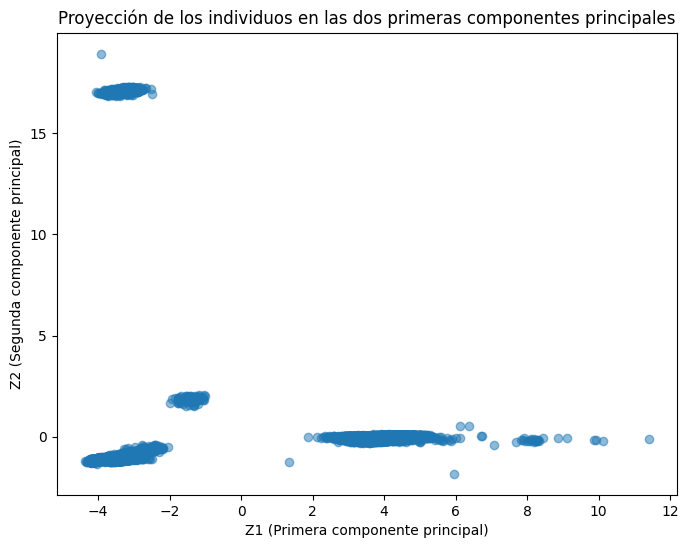

In [49]:
# Graficamos:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df_pca["Z1"], df_pca["Z2"], alpha=0.5)

plt.xlabel("Z1 (Primera componente principal)")
plt.ylabel("Z2 (Segunda componente principal)")
plt.title("Proyección de los individuos en las dos primeras componentes principales")

plt.show()

En el gráfico observamos regiones con mayor concentración de puntos, lo que sugiere la posible existencia de agrupamientos en los datos. Pueden observarse algunas bandas horizontales de puntos que corresponden a valores similares de la segunda componente principal.

Sin embargo, los grupos no aparecen completamente separados en esta proyección bidimensional, lo cual es esperable dado que las dos primeras componentes solo explican, aproximadamente, el 21.4 % de la varianza total. Es probable que parte de la estructura de los datos se encuentre en dimensiones superiores.

A continuación aplicamos métodos de clustering para identificar formalmente estos agrupamientos en los datos y analizar sus características.

## Ejercicio 11

**Clustering:** Realizar un agrupamiento de los datos por algún método de clustering entre los vistos en clase (K-means o DB-scan).Utilizar todas las columnas de datos (no las componentes
principales), seleccionado los hiperparámetros por algún mecanismo que consideren apropiado.

Agrupamos los datos por K-means o DB-scan. El dataset que estamos analizando contiene más de 37.000 observaciones y una gran cantidad de variables, muchas de las cuales son variables dummies.

En casos de alta dimensión, los métodos basados en densidad como DBSCAN suelen presentar dificultades, ya que las distancias entre puntos tienden a volverse menos informativas.

Por otro lado, K-means es un método eficiente para datasets grandes y de alta dimensión, especialmente cuando las variables han sido previamente normalizadas, como se hizo previamente. Por esta razón decidimos utilizar K-means para realizar el agrupamiento.

Para definir el número de clusters utilizamos el método del codo, analizando cómo varía la inercia del modelo al modificar el número de clusters.

In [50]:
# Estudiamos la inercia:

inercia = []
K = range(1,10)

for k in K:

    kmeans = KMeans(n_clusters=k, random_state=0)

    kmeans.fit(X_scaled)

    inercia.append(kmeans.inertia_)

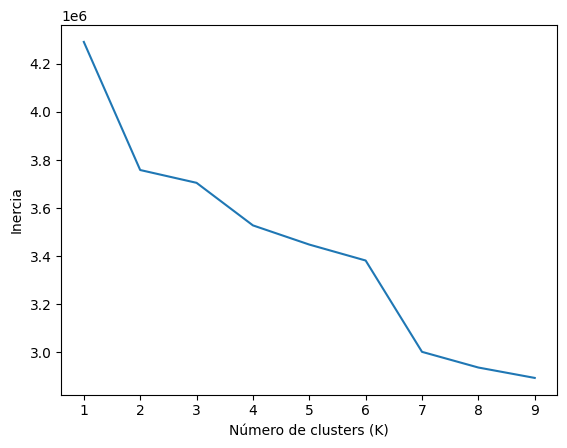

In [51]:
# Y graficamos para usar el método del codo:

import matplotlib.pyplot as plt

plt.plot(K, inercia)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")

plt.show()

In [52]:
for k, i in zip(K, inercia):
    print(k, i)

1 4290879.999999984
2 3758402.295538307
3 3705152.100844772
4 3528238.100415795
5 3448509.077149322
6 3382212.196920454
7 3002536.1363804066
8 2937345.7998431195
9 2894146.7746882765


Encontramos una gran reducción inicial de la inercia al pasar de K=1 a K=2, disminuyendo aproximadamente 532.000 unidades. Esta reducción es considerablemente mayor que las siguientes. lo cual es esperable ya que pasar de un único cluster a dos produce una mejora importante en la representación de los datos.

Al pasar de K=2 a K=3 la reducción de la inercia es mucho menor (aproximadamente 53.000), lo que indica que la mayor estructura global de los datos ya fue capturada con pocos clusters.

Para valores mayores de K la inercia continúa disminuyendo, pero con una reducción progresivamente más moderada. Disminuye gradualmente, con ello produciendo mejoras cada vez menores al agregar más clusters.

Entre K=6 y K=7 observamos una disminución márcada, lo que podría reflejar la aparición de subdivisiones adicionales dentro de los datos.

En el gráfico del método del codo no aparece un punto de quiebre extremadamente pronunciado, pero el cambio de pendiente más evidente ocurre en torno a K=3 y K = 4, donde la reducción de la inercia comienza a estabilizarse.

Por lo anterior, elegimos K = 4 como un valor razonable para el número de clusters, ya que permite capturar la estructura principal de los datos sin generar una partición excesivamente compleja.

Ajustamos el modelo con el K = 4 elegido:

In [53]:
# Ajustamos el modelo:

K_optimo = 4

kmeans = KMeans(n_clusters=K_optimo, random_state=0)

kmeans.fit(X_scaled)

labels = kmeans.labels_

## Ejercicio 12

Colorear los puntos del gráfico de dispersión de PCA según las etiquetas de los clusters. ¿Quedan los puntos de cada cluster ubicados cerca en esta visualización?


Para facilitar la interpretación de los clusters obtenidos mediante K-means, proyectamos los datos sobre las dos primeras componentes principales calculadas anteriormente y gráficamos.

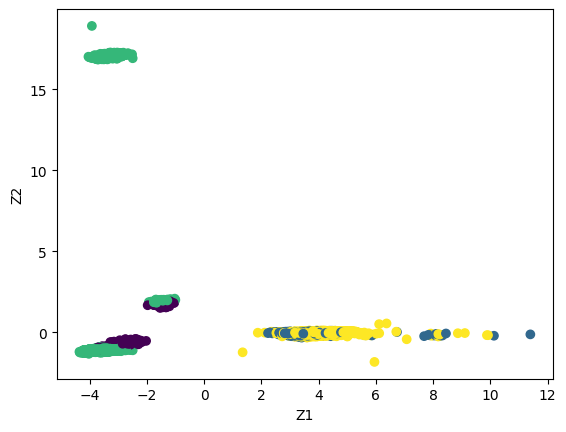

In [54]:
# Graficamos con los Z1 y Z2 previos:

import matplotlib.pyplot as plt

plt.scatter(df_pca["Z1"], df_pca["Z2"], c=labels)

plt.xlabel("Z1")
plt.ylabel("Z2")

plt.show()

En el gráfico se evidencia como algunos clusters se encuentran concentrados en regiones específicas del plano. En particular, observamos un cluster compacto ubicado en valores altos de la segunda componente principal Z2, claramente separado del resto de los puntos. También se distinguen otros grupos, relativamente compactos, en la zona izquierda del gráfico.

Por otro lado, el cluster que contiene la mayor cantidad de observaciones se distribuye principalmente en una banda horizontal cercana a Z2 ≈ 0, con cierta superposición con otros clusters.

Dado que las dos primeras componentes principales explican aproximadamente 21.4% de la varianza total del dataset, es esperable que la separación entre clusters no sea perfecta en esta representación bidimensional.

En general, los puntos pertenecientes a un mismo cluster tienden a ubicarse relativamente cerca entre sí en la proyección sobre las dos primeras componentes principales, aunque también se observa cierta superposición entre algunos clusters. Esto sugiere que el algoritmo K-means logró identificar agrupamientos en los datos, aunque la separación completa entre grupos no es completamente visible en esta proyección bidimensional.

## Ejercicio 13

**Identificación de grupos:** Queremos identificar las características de los distintos clusters. Para esto pueden utilizar cualquier estrategia que consideren apropiada. Por ejemplo,

  - Ver caraceterísticas de los individuos en los distintos clusters.
  - Si algunas de las componentes principales distingue clusters, ver qué palabras tienen peso en esa componente. Por ejemplo, si vemos que un cluster corresponde a individuos con coordenada Z1 alta, analizamos en las coordenadas de la dirección principal correspondiente qué variables tienen el mayor peso positivo.

Algunos clusters pueden no tener características claras. Identificar características en al menos 2 clusters del agrupamiento.

Tenemos, después de aplicar K-means, una partición del dataset en distintos clusters. Ahora vamos a identificar las características principales de estos grupos, es decir, determinar qué variables o patrones distinguen a los individuos de cada cluster.

Para ello analizamos algunas estadísticas descriptivas de los clusters y su relación con las componentes principales que obtuvimos anteriormente.

In [55]:
# Para analizar las características de cada grupo, añadimos las etiquetas del cluster al dataset:

df_clustering["cluster"] = labels

In [56]:
# Revisamos la cantidad de individuos en cada cluster, para identificar si existen clusters muy grandes o muy pequeños.
# Esto, como exploración previa, nos puede dar algún indicio sobre la estructura de los datos.

df_clustering["cluster"].value_counts()

,count
cluster,
2,18616
3,14240
1,3141
0,1315


Los clusters 2 y 3 concentran la mayor parte de las observaciones del dataset, mientras que los clusters 1 y 0 son grupos bastante más pequeños. Para entender mejor las diferencias entre clusters, calculamos los valores promedio de las variables dentro de cada grupo:

In [57]:
# Calculamos los valores promedio de las variables en cada cluster:

cluster_means = df_clustering.groupby("cluster").mean()

cluster_means

,EMPLEO,CH04,CH03,CH06,CH10,NIVEL_ED,PP3E_TOT,PP3F_TOT,PP04B1,PP04B2,...,PP04G_10.0,PP04G_11.0,PP04G_12.0,PP04G_13.0,SOLTERO,LEE,SECTOR_1.0,SECTOR_2.0,SECTOR_3.0,SECTOR_9.0
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000000,1.498099,3.093536,43.706464,1.975665,3.206844,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.520152,0.977947,0.000000,0.000000,0.000000,0.000000
1,1.744986,1.508118,2.096466,39.330468,1.909583,3.856415,28.140401,1.974530,1.853550,0.202483,...,0.008278,0.340019,0.046482,0.002547,0.423432,0.997453,0.355619,0.455906,0.148997,0.039478
2,0.000000,1.608025,2.571766,40.234905,1.571229,3.207349,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.544209,0.983509,0.000000,0.000000,0.000000,0.000000
3,1.404143,1.454635,1.958708,42.396559,1.934340,4.188062,38.511447,1.754635,1.933919,0.096910,...,0.010534,0.611376,0.048174,0.005407,0.335042,0.997121,0.691713,0.218258,0.066362,0.023525


In [58]:
# Encontramos que algunas variables presentan diferencias importantes entre los clusters:

cluster_means[[
"P47T",
"PP3E_TOT",
"PP04C",
"CH06",
"PP04B1",
"PP3F_TOT",
"EMPLEO",
"ESTADO_3",
"CH03",
"PP02F_2"
]].round(2)

# Redondeamos para que sea más legible.

,P47T,PP3E_TOT,PP04C,CH06,PP04B1,PP3F_TOT,EMPLEO,ESTADO_3,CH03,PP02F_2
cluster,,,,,,,,,,
0,156982.23,0.00,0.00,43.71,0.00,0.00,0.00,0.97,3.09,0.81
1,490782.01,28.14,3.11,39.33,1.85,1.97,1.74,0.00,2.10,0.00
2,250446.84,0.00,0.00,40.23,0.00,0.00,0.00,0.93,2.57,0.93
3,933985.08,38.51,5.26,42.40,1.93,1.75,1.40,0.00,1.96,0.00


Encontramos algunas diferencias entre los clusters: El cluster 3 presenta valores promedio muy altos en variables como P47T (ingreso laboral total), PP3E_TOT (horas trabajadas) y PP04C (condición de actividad laboral). Por ejemplo, el valor promedio de P47T en este grupo es aproximadamente 933985, mientras que en los otros clusters los valores son bastante menores (por ejemplo alrededor de 250446 en el cluster 2).

También se observa que variables como PP04B1 (tipo de ocupación), PP3F_TOT (horas adicionales trabajadas) y EMPLEO (indicador de empleo) toman valores positivos en este cluster, lo que refuerza la idea de que este grupo está asociado a individuos con mayor actividad laboral.

El cluster 1 muestra un patrón similar, aunque menos marcado. En este grupo las variables PP3E_TOT, PP04C y PP04B1 también presentan valores positivos, pero en general más bajos que en el cluster 3. Esto podría indicar que los individuos de este cluster también presentan actividad laboral, pero con características algo diferentes.

Por otro lado, los clusters 0 y 2 presentan valores cercanos a 0 en varias de las variables laborales anteriores. Esto sugiere que los individuos de estos grupos tienen menor presencia de estas características. Además, estos clusters presentan valores relativamente altos en ESTADO_3 (situación ocupacional), lo cual podría estar asociado a otra condición dentro del mercado laboral.

Por otro lado, los clusters 0 y 2 presentan valores cercanos a 0 en varias de las variables laborales mencionadas anteriormente. Esto sugiere que los individuos de estos grupos tienen menor presencia de estas características. Por ejemplo, en ambos clusters las variables PP3E_TOT, PP04C y PP04B1 son prácticamente cero.

Además, estos clusters presentan valores relativamente altos en ESTADO_3, lo cual podría estar asociado a una situación ocupacional distinta a la observada en los clusters anteriores.

Al observar el gráfico de las componentes principales coloreado por cluster (Ejercicio 12), notamos que algunos clusters aparecen más concentrados en regiones específicas del plano, mientras que otros presentan cierta superposición.

Esto es esperable dado que las dos primeras componentes principales explican solo una parte de la variabilidad total del dataset.

A partir del análisis de las variables promedio por cluster, se pueden identificar algunas características que distinguen a los distintos grupos obtenidos mediante K-means.

En particular, el cluster 3 parece corresponder a individuos con valores más altos en varias variables relacionadas con el empleo y los ingresos laborales. El cluster 1 presenta características similares, aunque menos marcadas. Por otro lado, los clusters 0 y 2 muestran menor presencia de estas variables, lo que podría indicar situaciones ocupacionales diferentes.

Estos resultados sugieren la existencia de distintos perfiles dentro del dataset, asociados a diferentes combinaciones de características laborales y sociodemográficas.

Cabe notar que, dado que el clustering se realizó en un espacio de alta dimensión, la separación entre grupos no siempre es completamente clara en la visualización mediante PCA. Sin embargo, el análisis de las variables promedio por cluster permite identificar patrones que ayudan a interpretar los agrupamientos encontrados.

# Clasificaciòn

Queremos predecir ahora para las personas que est´an empleadas, si el trabajo que tienen es formal,
informal o servicio dom´estico (categor´ıas 1, 2 y 3 de la variable SECTOR) y analizar que variables
influyen en el tipo de trabajo.


## Ejercicio 14

Generar un DataFrame df_clasificacion que contenga solo los individuos con valores 1, 2 o
3 en la columna SECTOR.

In [59]:
# Creamos un nuevo DataFrame df_clasificacion, con únicamente las observaciones cuyo valor de SECTOR corresponde a alguna de las tres categorías de interés:

df_clasificacion = df_clean[df_clean["SECTOR"].isin([1, 2, 3])].copy()


In [60]:
# Verificamos SECTOR en el nuevo DataFrame:

df_clasificacion["SECTOR"].value_counts()

,count
SECTOR,
1.0,10967
2.0,4540
3.0,1413


## Ejercicio 15

Eliminar a los indiduos con ingreso total = 0 (variable P47T) y reemplazar esta variable por
su logaritmo (para evitar valores muy grandes).

La variable P47T representa el ingreso total individual, que incluye tanto ingresos laborales como no laborales. Antes de aplicar  las transformaciones, exploramos la distribución de esta variable:

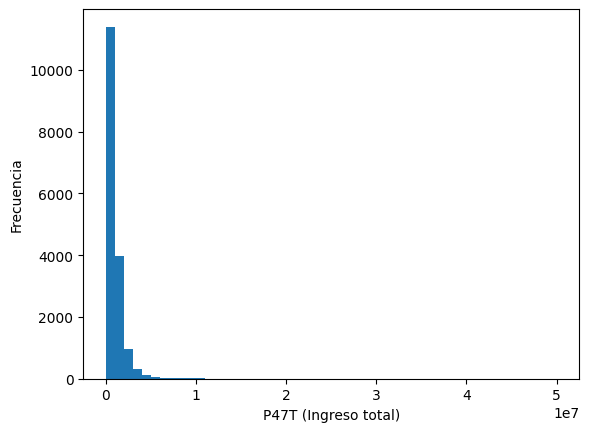

In [61]:
import matplotlib.pyplot as plt

plt.hist(df_clasificacion["P47T"], bins=50)

plt.xlabel("P47T (Ingreso total)")
plt.ylabel("Frecuencia")

plt.show()

A partir del gráfico se observa que la variable P47T presenta una distribución muy asimétrica, sesgada hacia la derecha, con gran concentración de observaciones en valores bajos y algunos valores muy elevados. Este tipo de distribución es común en variables de ingreso.

Para reducir esta asimetría y evitar que los valores extremos dominen el análisis, se aplicará una transformación logarítmica sobre la variable.

Esta variable puede tomar valor 0, para el caso de las personas sin ingreso. Sin embargo, el logaritmo no está definido para valores iguales a cero. Por esta razón, primero eliminamos las observaciones cuyo ingreso total sea igual a cero.

In [62]:
# Sacamos los valores iguales a 0, dejando solo los mayores a 0 (Es una variable de ingreso, no admite valores negativos):

df_clasificacion = df_clasificacion[df_clasificacion["P47T"] > 0].copy()

In [63]:
# Aplicamos La transformación logarítmica ra P47T.
# Esto reduce la dispersión de la variable y nos permite trabajar con valores más comparables entre sí:

df_clasificacion["P47T"] = np.log(df_clasificacion["P47T"])

Para visualizar el efecto de la transformación, graficamos para comparar la distribución de la variable antes y después de aplicar el logaritmo.

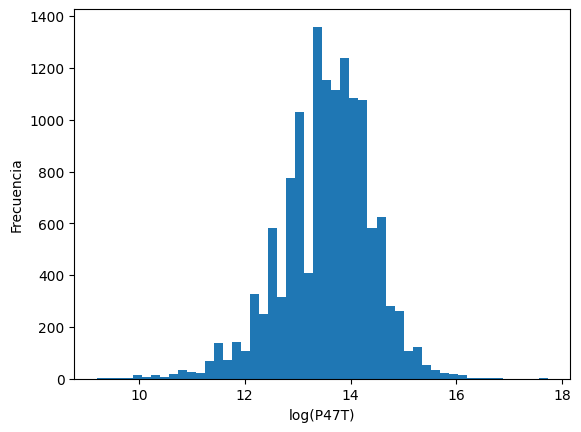

In [64]:
# Graficamos nuevamente tras reemplazar con el logaritmo:

plt.hist(df_clasificacion["P47T"], bins=50)

plt.xlabel("log(P47T)")
plt.ylabel("Frecuencia")

plt.show()

La distribución de la variable se presenta ahora más compacta y menos asimétrica.

## Ejercicio 16

Visualizaci´on. Normalizar las variables. calcular las dos primeras componentes principales
Z1 y Z2 del DataFrame df_clasificacion y realizar un gr´afico de dispersi´on de Z1 vs. Z2,
coloreando cada punto seg´un el SECTOR
¿Quedan los individuos de cada sector cerca en esta visualizaci´on?

La variable SECTOR corresponde a la variable objetivo del problema de clasificación. Por esta razón, no se utiliza como variable explicativa en el cálculo de las componentes principales ni se incluye en el proceso de normalización.

La usaremos únicamente para colorear los puntos del gráfico.

In [65]:
# Separamos las variables predictoras y la variable objetivo:

X = df_clasificacion.drop(columns=["SECTOR"])
y = df_clasificacion["SECTOR"]

Antes de aplicar PCA normalizamos las variables para evitar que las mayores dominen el análisis.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [67]:
# Calculamos las primeras dos componentes principales:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca.fit(X_scaled)

Z = pca.transform(X_scaled)

In [68]:
# Construimos un DataFrame con ellas para graficar:


df_pca_clasificacion = pd.DataFrame(Z, columns=["Z1","Z2"])

df_pca_clasificacion["SECTOR"] = y.values

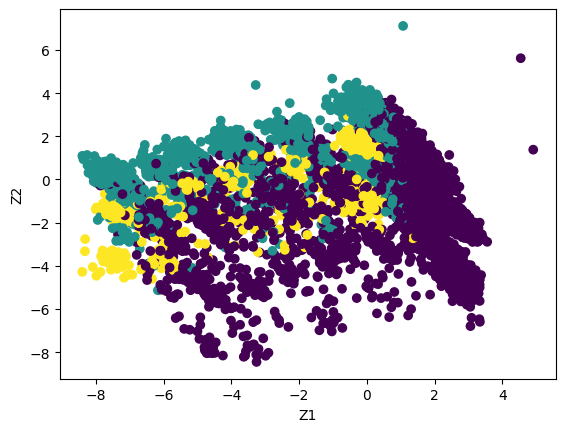

In [69]:
# Generamos el gráfico de dispersión con Z1 y Z2.
# Cada punto representa un individuo y su color indica el sector de empleo al que pertenece:

plt.scatter(
    df_pca_clasificacion["Z1"],
    df_pca_clasificacion["Z2"],
    c=df_pca_clasificacion["SECTOR"]
)

plt.xlabel("Z1")
plt.ylabel("Z2")

plt.show()

En el gráfico observamos que los individuos pertenecientes a los distintos sectores se encuentran bastante mezclados en el espacio definido por las dos primeras componentes principales. No se observa una separación clara entre los tres grupos.

Sin embargo, pueden identificarse algunas zonas donde ciertos sectores parecen concentrarse con mayor frecuencia. Por ejemplo, algunos puntos asociados a determinados sectores tienden a aparecer en regiones específicas del gráfico, aunque con una superposición considerable entre grupos.

Esto indica que las dos primeras componentes principales no permiten separar claramente los sectores de empleo en esta representación bidimensional.

La proyección mediante PCA permite visualizar parcialmente la estructura de los datos, pero en este caso los individuos de cada sector no quedan claramente agrupados en regiones separadas del gráfico. Esto sugiere que la distinción entre sectores depende de combinaciones más complejas de variables que no se capturan completamente en las dos primeras componentes principales.

## Ejercicio 17

Predecir el sector de cada individuo utilizando KNN. Para esto:
  
  (a) separar el conjunto total de datos en un 80 % para entrenamiento y un 20 % para testeo,

  (b) normalizar las variables en el conjunto de entrenamiento.

  (c) seleccionar el valor de K (entre n´umeros impares del 1 al 19 ambos inclusive) por alg´un esquema de validaci´on apropiado en el conjunto de entrenamiento (train-validation, crossvalidation, leave-one-out),
  
  (d) para el valor hallado, calcular la precisi´on del m´etodo (porcentaje de aciertos) en el conjunto de testeo (recordar normalizar los datos con la misma transformaci´on).
  
  (e) ¿Qu´e variables son valiosas para clasificar el sector de trabajo? Elegir 3 variables que ustedes consideren valiosas a priori y realicen alg´un experimento para verificarlo. Por ejemplo, pueden ver como se afectan las predicciones si eliminamos esas variables.


(a) Separar el conjunto total de datos en un 80 % para entrenamiento y un 20 % para testeo.

In [70]:
# Separamos las variables predictoras y la objetivo:

X = df_clasificacion.drop(columns=["SECTOR"])
y = df_clasificacion["SECTOR"]

In [71]:
# Aplicamos la división a los datos:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0 # Para que la división sea reproducible
)

In [72]:
# Verificamos:

X_train.shape, X_test.shape

print("Proporción del Train:",10813 / (10813 + 2704))
print("Propoción del Test:",2704 / (10813 + 2704))

Proporción del Train: 0.7999556114522454
Propoción del Test: 0.2000443885477547


La división produce aproximadamente un 80 % de observaciones en el conjunto de entrenamiento (10813 individuos) y un 20 % en el conjunto de testeo (2704 individuos).

### (b)

Normalizar las variables en el conjunto de entrenamiento.

Necesitamos que las variables estén en escalas comparables, dado que el algoritmo KNN se basa en distancias entre observaciones.  Para ello normalizamos las variables utilizando StandardScaler.

Es importante que el escalado se ajuste únicamente con el conjunto de entrenamiento, para evitar utilizar información del conjunto de test durante el entrenamiento del modelo.

In [73]:
# Normalizamos:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [74]:
# Verificamos:

X_train_scaled.mean(), X_train_scaled.std()

(np.float64(-2.8162241313766505e-18), np.float64(0.807332468246951))

Tras aplicar la normalización, las variables quedan aproximadamente centradas en 0 y con desviación estándar cercana a 1.

### (c)

Seleccionar el valor de K (entre n´umeros impares del 1 al 19 ambos inclusive) por alg´un
esquema de validaci´on apropiado en el conjunto de entrenamiento (train-validation, crossvalidation, leave-one-out)

Para aplicar KNN necesitamos elegir el número de vecinos K, parámetro controla cuántos vecinos se consideran al momento de clasificar cada observación.

Valores pequeños de K pueden producir modelos muy sensibles al ruido, mientras que valores grandes pueden generar modelos demasiado suavizados.

Evaluamos el desempeño del modelo para distintos valores de K con Cross-Validation sobre el conjunto de entrenamiento.

Se consideran valores impares entre 1 y 19, ya que los valores impares ayudan a evitar empates en la votación entre vecinos.

In [75]:
# Evaluamos para distintos valores de K:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1,20,2) # De 1 a 19, avanzando de 2 en 2.

scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    score = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5 # Valor estándar muy utilizado
    ).mean()

    scores.append(score)

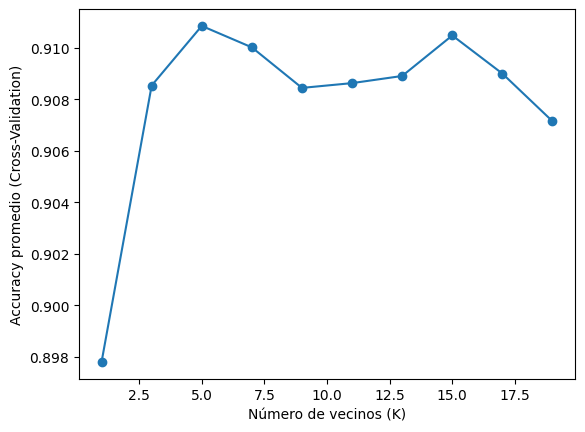

In [76]:
# Graficamos el accurancy promedio con cada K para analizar como cambia la precisión del modelo:

import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker="o")

plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio (Cross-Validation)")

plt.show()

In [77]:
# Seleccionamos el valor que produce el mayor accuracy promedio en la validación cruzada:

best_k = k_values[np.argmax(scores)]

best_k

5

 En el gráfico observamos como el desempeño del modelo aumenta considerablemente al pasar de K = 1 a K = 3. Esto nos indica que utilizar un único vecino podría dar un modelo demasiado sensible al ruido en los datos. A partir de K = 3 el desempeño se estabiliza y alcanza su valor máximo alrededor de K = 5.

Para valores mayores de K, el accuracy se mantiene relativamente estable pero no mejora respecto al obtenido con K = 5. En algunos casos incluso se observa una ligera disminución del desempeño.

Por esta razón elegimos a K = 5 como valor óptimo del número de vecinos, ya que produce el mayor accuracy promedio en validación cruzada dentro del rango evaluado.

### (d)

Para el valor hallado, calcular la precisi´on del m´etodo (porcentaje de aciertos) en el conjunto de testeo (recordar normalizar los datos con la misma transformaci´on).

Con el valor óptimo K = 5 seleccionado entrenamos el modelo KNN. Utilizamos el conjunto completo de entrenamiento y luego evaluamos su desempeño sobre el conjunto de test.

In [78]:
# Entrenamos el modelo:

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [79]:
# Cálculamos la precisión en el conjunto de test:

accuracy = knn.score(X_test_scaled, y_test)

accuracy

0.9149408284023669

Obtenemos una precisión de aproximadamente 0.9149, oequivalente a aproximadamente 91.5 % de aciertos en el conjunto de test. Este resultado indica que el modelo KNN con K = 5 logra clasificar correctamente el sector de trabajo en aproximadamente 9 de cada 10 individuos del conjunto de test.

Dado que estos datos no fueron utilizados durante el entrenamiento del modelo, esta medida proporciona una estimación razonable del desempeño del modelo sobre nuevos datos.

La precisión obtenida sugiere que las variables incluidas en el dataset contienen información relevante para distinguir entre los distintos sectores de empleo.

### (e)

¿Qu´e variables son valiosas para clasificar el sector de trabajo? Elegir 3 variables que
ustedes consideren valiosas a priori y realicen alg´un experimento para verificarlo. Por
ejemplo, pueden ver como se afectan las predicciones si eliminamos esas variables.


Iniciamos explorando algunas diferencias entre sectores en el dataset. Comparamos los valores promedio de algunas variables según el sector de trabajo.

Elegimos las variables P47T (ingreso total individual),CH06 (edad) y EMPLEO (indicador de empleo), que podrían estar relacionadas con las características laborales y el tipo de trabajo de los individuos. Por ejemplo, es razonable esperar que el ingreso total (P47T) difiera entre trabajo formal, informal y servicio doméstico. Asimismo, la edad (CH06) podría estar asociada a distintos tipos de ocupación. Evaluamos los datos y verificamos.

In [80]:
# Exploramos las variables:

df_clasificacion.groupby("SECTOR")[["P47T","CH06","EMPLEO"]].mean()

,P47T,CH06,EMPLEO
SECTOR,,,
1.0,13.859888,41.871148,1.178599
2.0,12.990569,40.674884,2.000000
3.0,12.862052,43.612762,1.801573


Se encuentran diferencias en el ingreso total individual (P47T) entre los distintos sectores. El sector 1 presenta un ingreso promedio mayor que los sectores 2 y 3. Esto es consistente con la idea de que el trabajo formal suele estar asociado a mayores ingresos.

También observamos diferencias en la edad (CH06). El sector 3 presenta un promedio de edad ligeramente mayor que los otros sectores, lo cual podría reflejar diferencias en la composición etaria de los trabajadores en cada sector.

La variable EMPLEO varía entre sectores, lo cual sugiere que también podría aportar información relevante para distinguir entre tipos de trabajo.

Tras esta exploración preliminar seleccionamos a estas como posibles variables relevantes en la clasificación. Para evaluar la importancia de las mismas, las eliminamos de los datos y entrenamos nuevamente el modelo KNN.

In [81]:
# Excluimos las variables y nos quedamos con los datos restantes:

X_reducido = X.drop(columns=["P47T","CH06","EMPLEO"])

In [82]:
# Dividos los datos para entrenamiento y testeo:

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reducido,
    y,
    test_size=0.2,
    random_state=0
)

In [83]:
# Normalizamos:

scaler_r = StandardScaler()

X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [84]:
# Y entrenamos nuevamente el modelo:

knn_r = KNeighborsClassifier(n_neighbors=best_k)

knn_r.fit(X_train_r_scaled, y_train_r)

KNeighborsClassifier()

In [85]:
# Calculamos la precisión:

accuracy_reduced = knn_r.score(X_test_r_scaled, y_test_r)

accuracy_reduced

0.8631656804733728

Con modelo KNN entrenado sin estas variables obtenemos una precisión de aproximadamente 0.863, que contrasta con el 0.9149 obtenido con el modelo original.

Luego, al excluir las variables P47T (ingreso total), CH06 (edad) y EMPLEO, obtenemos una reducción en la precisión del modelo de aproximadamente 91.5% a 86.3%.

Esto sugiere que las variables elegidas aportan información relevante para la clasificación del sector de trabajo y son significativas para que el modelo pueda distinguir entre distintos sectores de empleo.

# Regresión

Queremos ahora predecir el sueldo de las personas ocupadas.

##Ejercicio 18

Generar un DataFrame df_regresion que contenga solo las personas ocupadas, con ingreso
total positivo (variable P47T).

La variable para la condición de actividad, "ESTADO", toma los valores:

   - 1  = Ocupado
   - 2  = Desocupado
   - 3  = Inactivo

Para nuestro conjunto de datos, en ejercicios previos esta variable fue transformada en dummies, generándose las variables "ESTADO_2" y "ESTADO_3". La categoría omitida corresponde a ESTADO = 1, es decir, personas ocupadas. No se generó pues pd.get_dummies() evita colinealidad, donde ESTADO = 1  es equivalente a tener ESTADO_2 = 0  y  ESTADO_3 = 0.

Filtramos los datos para aquellos con estos valores. La variable "P47T" representa el ingreso total individual. Dado que el logaritmo solo está definido para valores positivos, se restringe el análisis a observaciones con P47T > 0.

In [87]:
# Generamos el nuevo DataFrame con personas ocupadas que tengan ingreso total positivo:

df_regresion = df_clean[
    (df_clean["ESTADO_2"] == 0) &
    (df_clean["ESTADO_3"] == 0) &
    (df_clean["P47T"] > 0)
].copy()

##Ejercicio 19

Reemplazar la variable P47T por su logaritmo

In [88]:
# Primero revisamos la distribución de la variable.
# Con este resumen podemos observar la magnitud y dispersión de los valores de ingreso:

df_regresion["P47T"].describe()

,P47T
count,1.385600e+04
mean,1.055249e+06
std,1.083672e+06
min,1.000000e+04
25%,4.800000e+05
50%,8.000000e+05
75%,1.300000e+06
max,5.000000e+07


La variable P47T presenta valores muy elevados en comparación con la mediana del ingreso. Esto indica la presencia de valores extremos de ingreso.

Para reducir la influencia de estos y estabilizar la variabilidad de la variable objetivo, aplicamos una transformación logarítmica al ingreso.

Dado que en el ejercicio anterior restringimos los datos a aquellos con P47T > 0, se puede aplicar directamente el logaritmo1.

In [89]:
df_regresion["log_P47T"] = np.log(df_regresion["P47T"])

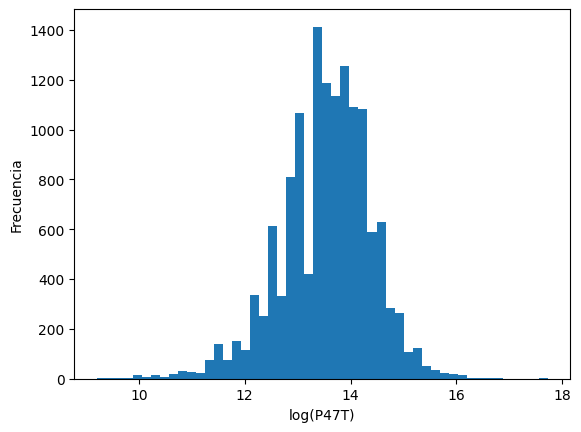

In [90]:
# Visualizamos:


plt.hist(df_regresion["log_P47T"], bins=50)

plt.xlabel("log(P47T)")
plt.ylabel("Frecuencia")

plt.show()

##Ejercicio 20

Proponer tres modelos distintos para ajustar la variable P47T transformada (pueden incluir
distintas variables, regresi´on ordinaria, Ridge, redes neuronales, ...).
3

Queremos predecir el ingreso de los individuos ocupados. La variable objetivo corresponde al logaritmo del ingreso total, definida en el ejercicio anterior.

Proponemos tres modelos con enfoques distintos y analizamos si métodos más complejos o distintas selecciones de variables permiten mejorar el desempeño del modelo.

Los modelos a considerar son:

  - Regresión lineal ordinaria

  - Regresión Ridge

  - Regresión lineal con un subconjunto de variables relevantes

In [91]:
# Separamos las variables explicativas y objetivo:

X = df_regresion.drop(columns=["P47T", "log_P47T"])
y = df_regresion["log_P47T"]

In [92]:
# Dividimos los datos para entrenamiento y testeo:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

#### Modelo 1: Regresión lineal

Iniciamos con una regresión lineal como modelo base, para analizar la relación entre las variables explicativas y el ingreso de una manera más directa y simple.




In [99]:
# El modelo:

modelo_linear = LinearRegression()

# Ajustamos:

modelo_linear.fit(X_train, y_train)

# Calculamos el R²:

r2_linear = modelo_linear.score(X_test, y_test)

r2_linear

0.507250896883318

El coeficiente R² obtenido, de aproximadamente 0.507, indica que el modelo logra explicar aproximadamente el 50% de la variabilidad. Esto sugiere que las variables disponibles contienen información relevante para explicar el ingreso, aunque existe una proporción importante de variabilidad que no es capturada por el modelo.

Este nos sirve como referencia para comparar los demás enfoques.

#### Modelo 2: Regresión Ridge

Como segundo modelo utilizamos una regresión Ridge, una modificación de la regresión lineal que penaliza al tamaño de los coeficientes.

Esta penalización puede ayudar a mejorar la estabilidad del modelo cuando el número de variables explicativas es grande o cuando existe correlación entre ellas.

Dado que tenemos un número elevado de variables, resulta razonable evaluar si este tipo de regularización puede mejorar el desempeño del modelo.

Los modelos de este tipo son sensibles a la escala de las variables, por lo que primero normalizamos los datos.

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Normalizamos los datos:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# El modelo:

modelo_ridge = Ridge()

# Ajustamos:

modelo_ridge.fit(X_train_scaled, y_train)

# Calculamos su R²:

r2_ridge = modelo_ridge.score(X_test_scaled, y_test)

r2_ridge

0.5072520984757158

Obtenemos un R² de aproximadamente 0.507, muy similar al de la regresión lineal ordinaria. Esto sugiere que, con el valor por defecto del hiperparámetro (acá no lo alteramos), la penalización introducida por el modelo Ridge no produce una mejora significativa respecto al modelo lineal.

Sin embargo, el modelo Ridge depende este para controlar la intensidad de esta penalización, por lo que en el siguiente ejercicio se buscaremos su valor óptimo mediante un procedimiento de validación.

#### Modelo 3: Regresión lineal con subconjunto de variables.

Como tercer modelo ajustamos una regresión lineal utilizando un subconjunto reducido de variables que consideramos pueden ser relevantes para explicar el ingreso. Este enfoque nos permite evaluar si un modelo más simple puede obtener resultados comparables.

Las variables seleccionadas son:

  - "CH06" : Edad

  - "NIVEL_ED": Nivel educativo

  - "SECTOR" : Sector de trabajo

Las elegimos porque suelen estar asociadas con diferencias salariales en el mercado laboral.

In [101]:
# Seleccionamos las variables para el modelo:

variables_modelo3 = ["CH06", "NIVEL_ED", "SECTOR"]

# Dividimos los datos para el entrenamiento y el testeo:

X_train_red = X_train[variables_modelo3]
X_test_red = X_test[variables_modelo3]

# El modelo:

modelo_reducido = LinearRegression()

# Ajustamos:

modelo_reducido.fit(X_train_red, y_train)

# Calculamos su R²:

r2_reducido = modelo_reducido.score(X_test_red, y_test)

r2_reducido

0.20231578521277138

 Obtenemos un R² de aproximadamente 0.202, un desempeño considerablemente menor que los modelos que utilizan todas las variables. Esto nos indica que, aunque variables como la edad, el nivel educativo y el sector de trabajo están relacionadas con el ingreso, no son suficientes por sí solas para explicar la variabilidad del salario.

El ingreso entonces parece depender de una combinación más amplia de características presentes en los datos.

Los resultados muestran que los modelos que utilizan todas las variables disponibles logran explicar una proporción considerablemente mayor de la variabilidad del ingreso que el modelo reducido.

Por otro lado, el modelo Ridge no muestra mejoras evidentes respecto a la regresión lineal con el valor por defecto del hiperparámetro. En el siguiente ejercicio buscamos seleccionar el valor óptimo de este hiperparámetro mediante un procedimiento de validación.

##Ejercicio 21

Al menos uno de los modelos propuestos debe depender de hiperparámetros. Seleccionar los
hiperparámetros por alguna metodologáa apropiada.

El modelo Ridge depende de un hiperparámetro α que controla la intensidad de la penalización aplicada a los coeficientes del modelo.

Como se presentó antes, valores pequeños de este parámetro generan un modelo muy similar a la regresión lineal ordinaria.

Para seleccionar el valor adecuado del hiperparámetro usamos cross-validation en el conjunto de datos de entrenamiento. Esto nos permite evaluar el desempeño del modelo para distintos valores de α en distintas particiones de los datos, reduciendo la dependencia del resultado de una única división de los mismos.



In [102]:
from sklearn.model_selection import cross_val_score

# Estudiamos algunos posibles valores para α:

alphas = [0.01, 0.1, 1, 10, 100, 500, 1000, 1500]

scores = []

# Usamos Cross-Validation:


for alpha in alphas:

    modelo = Ridge(alpha=alpha)

    score = cross_val_score(
        modelo,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    ).mean()

    scores.append(score)

for a, s in zip(alphas, scores):
    print(a, s)

0.01 0.4725790310748222
0.1 0.47257920634187284
1 0.4725809555022466
10 0.4725980984813932
100 0.4727368211012255
500 0.4728023636422023
1000 0.4720573261284381
1500 0.47074132026708837


In [103]:
# Seleccionamos el mejor α:

mejor_alpha = alphas[np.argmax(scores)]

mejor_alpha

500

Obtenemos que el mejor valor para el hiperparámetro es α=500.

In [107]:
# El modelo con el valor obtenido:

modelo_ridge_opt = Ridge(alpha=mejor_alpha)

# Ajustamos:

modelo_ridge_opt.fit(X_train_scaled, y_train)

# Calculamos su  R²:

r2_ridge_opt = modelo_ridge_opt.score(X_test_scaled, y_test)

r2_ridge_opt

0.5072863359063096

El valor seleccionado para el hiperparámetro α=500. Al ajustar el modelo con este valor se obtiene un coeficiente R² de aproximadamente 0.507, muy similar al obtenido con la regresión lineal ordinaria.

Esto sugiere que, en este dataset, la regularización introducida por el modelo Ridge no produce una mejora sustancial en la capacidad predictiva del modelo, aunque permite controlar el tamaño de los coeficientes y potencialmente mejorar la estabilidad del modelo. Esto indica que la relación entre las variables explicativas y el ingreso puede capturarse razonablemente bien mediante un modelo lineal.



##Ejercicio 22

Seleccionar el mejor de los 3 modelos mediante un esquema de validación apropiado, e indicar el RSME en un conjunto de datos de testeo no utilizado previamente.

En los ejercicios anteriores planteamos tres modelos distintos para predecir el ingreso de los individuos ocupados: Regresión lineal, Regresión Ridge y Regresión lineal con un subconjunto reducido de variables.

Además, seleccionamos el valor óptimo del hiperparámetro del modelo Ridge (α=500) mediante Cross-Validation. Para comparar los modelos utilizamos los valores del coeficiente R² obtenidos en el conjunto de test:

  - Regresión lineal: R² = 0.507
  - Ridge: R² = 0.507
  - Modelo reducido	R² = 0.202

Los resultados nos muestran que los modelos que utilizan todas las variables disponibles logran explicar una proporción considerablemente mayor de la variabilidad del ingreso que el modelo reducido.

Por otra parte, el modelo Ridge presenta un desempeño muy similar al de la regresión lineal, aunque ligeramente superior al utilizar el valor óptimo del hiperparámetro obtenido mediante validación cruzada.

Por esta razón, seleccionamos modelo Ridge con hiperparámetro α=500 como modelo final. Para evaluar su desempeño calculamos el RMSE en el conjunto de test, que mide el error promedio de las predicciones:

In [110]:
from sklearn.metrics import mean_squared_error

# No utilizamos el conjunto de testeo ni durante el entrenamiento del modelo ni durante la selección del hiperparámetro,
# Luego, podemos usar el conjunto de testeo para obtener una estimación independiente del error de predicción:


y_pred_ridge = modelo_ridge_opt.predict(X_test_scaled)

# Calculamos el RMSE:

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

rmse

np.float64(0.5900561273504129)

Obtenemos un RMSE de aproximadamente 0.59, el error promedio del modelo en la predicción del logaritmo del ingreso.

Este muestra que, aunque el modelo captura una porción importante de la variabilidad, existe una parte importante que no puede ser explicada únicamente a partir de las variables disponibles en nuestros datos.


##Ejercicio 23

Seleccionar tres variables que consideren interesantes para evaluar la influencia de las mismas
en el salario de una persona. Realizar alg´un experimento simple para ver la influencia seg´un el
modelo seleccionado en el ´ıtem anterior.

Nota: En modelos lineales podr´ıa simplemente observarse el coeficiente correspondiente. En otros modelos no se puede hacer este an´alisis pero podemos analizar por ejemplo que sucede cuando modificamos una variable. Por ejemplo, si queremos analizar el efecto del Sexo, podemos comparar el salario promedio cuando reemplazamos en todas nuestras observaciones el sexo por varon y el salario promedio reemplazando el sexo por mujer.

Para este análisis seleccionamos tres variables que resultan relevantes desde el punto de vista económico:

    - "CH06": Edad

    - "NIVEL_ED": Nivel educativo alcanzado

    - "PP04B1": Situación laboral

Consideramos estas variables como relevantes porque factores como la edad (que puede reflejar experiencia laboral, pero también hacer al individuo menos atractivo para el mercado), el nivel educativo y la situación laboral suelen estar asociados con diferencias en los ingresos.

In [112]:
# Obtenemos los coeficientes del modelo:

coeficientes = pd.Series(
    modelo_ridge_opt.coef_,
    index=X.columns
)

coeficientes[["CH06", "NIVEL_ED", "PP04B1"]]

,0
CH06,0.107080
NIVEL_ED,0.144974
PP04B1,0.029163


Obtenemos los coeficientes: CH06	0.107 para "CH06", 0.145 para "NIVEL_ED" y 0.029 para "PP04B1".

Los coeficientes nos indican cómo cambia el valor esperado de la variable objetivo cuando una variable explicativa aumenta en una unidad cuando mantenemos a las demás constantes.

Dado que la variable objetivo corresponde al logaritmo del ingreso, los coeficientes pueden interpretarse aproximadamente como cambios proporcionales en el ingreso.

"NIVEL_ED" presenta el coeficiente más alto (0.145), lo que indica que el nivel educativo parece tener una influencia importante sobre el ingreso. Esto es consistente con la idea de que mayores niveles educativos suelen asociarse con mejores oportunidades laborales y mayores salarios.

"CH06" (la edad) también presenta un coeficiente positivo (0.107), lo que sugiere que, en promedio, los individuos de mayor edad tienden a tener ingresos más altos. Esto puede estar relacionado con la acumulación de experiencia laboral.

"PP04B1" presenta un coeficiente positivo menor (0.029), lo que nos indica que la situación laboral capturada por esta variable también tiene influencia sobre el ingreso, aunque de menor magnitud en comparación con las otras variables analizadas.

En conjunto, estos resultados sugieren que factores como la educación, la edad y las características laborales contribuyen a explicar las diferencias en el ingreso de los individuos.